# Primary Goal: Predict wine quality and understand the factors influencing it.
# Additional Goals:
* Identify important features for quality prediction.
* Cluster wines into groups based on chemical properties.
* Provide actionable insights for winemakers.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, silhouette_score

# Data Sources:

* Two datasets: winequality-red.csv and winequality-white.csv.
* Attributes include physicochemical properties (e.g., acidity, residual sugar) and sensory-based wine quality (score: 0–10).

In [ ]:
from google.colab import files
uploaded = files.upload()

red_wine = pd.read_csv('winequality-red.csv', sep=';')
white_wine = pd.read_csv('winequality-white.csv', sep=';')

# 'type' column to distinguish wine types
red_wine['type'] = 'red'
white_wine['type'] = 'white'

# Combining the datasets
wines = pd.concat([red_wine, white_wine], axis=0)

# Inspecting the dataset
print("Dataset Info:")
print(wines.info())
print("\nDataset Description:")
print(wines.describe())
print("\nFirst few rows of data:")
print(wines.head())

Saving winequality-red.csv to winequality-red (1).csv
Saving winequality-white.csv to winequality-white (1).csv
Dataset Info:
<class 'pandas.core.frame.DataFrame'>
Index: 6497 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes:

## Dataset Size:

- Red wines: 1,599 samples.
- White wines: 4,898 samples.

## Key Features:

- Inputs: 11 physicochemical attributes (e.g., alcohol, pH).
- Output: Quality score (ordinal, 0–10).

# Exploratory Data Analysis (EDA)


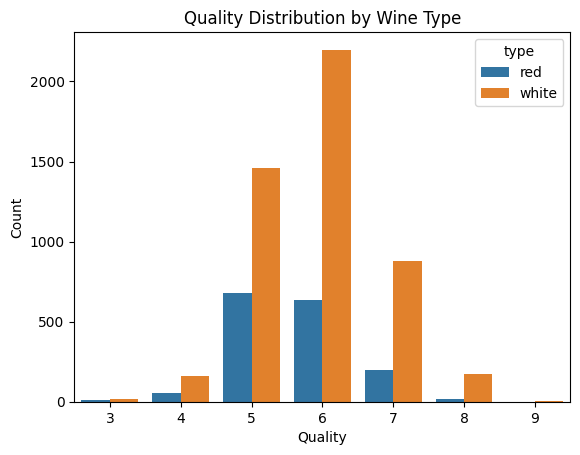

In [ ]:
# Quality Distribution
sns.countplot(data=wines, x='quality', hue='type')
plt.title("Quality Distribution by Wine Type")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.show()

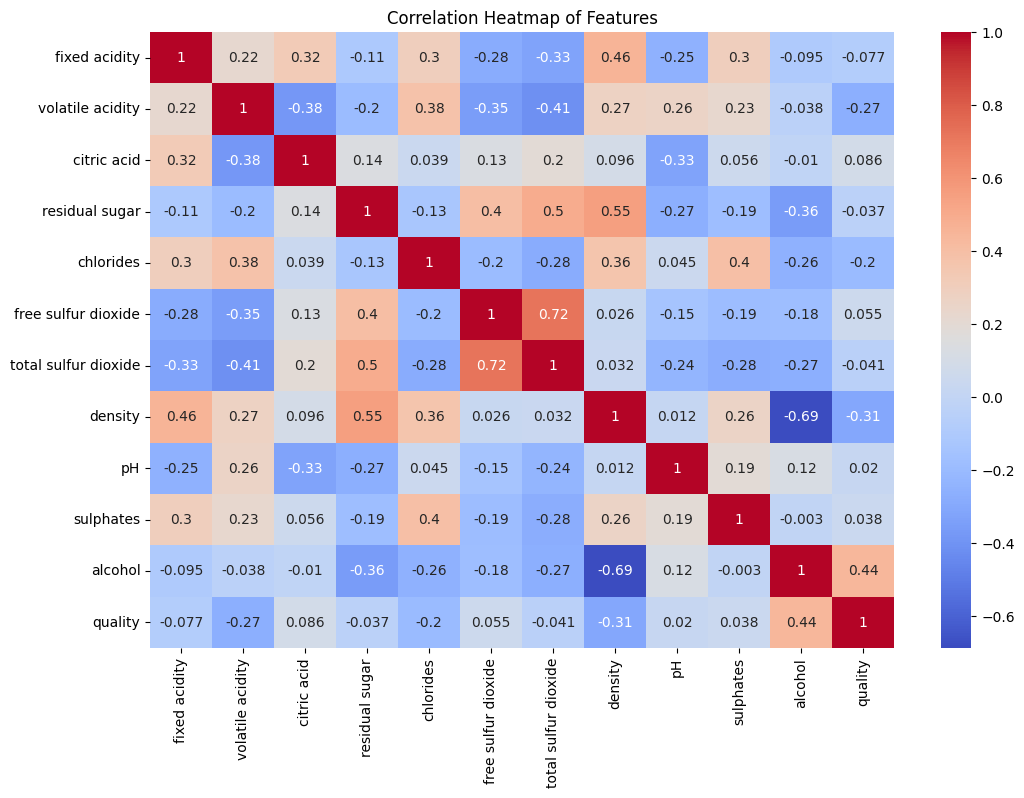

In [ ]:
# Correlation Heatmap
correlation_matrix = wines.drop(columns=['type'], errors='ignore').corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Features")
plt.show()

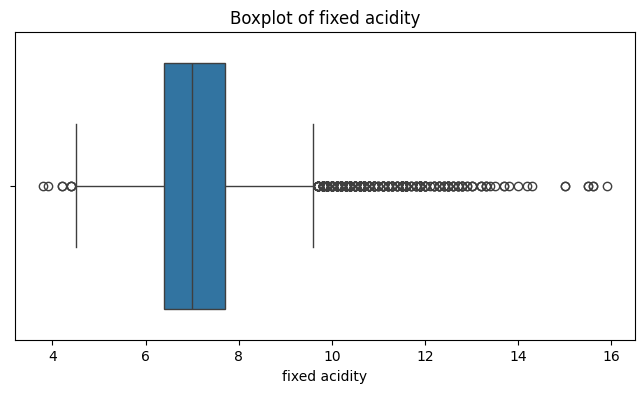

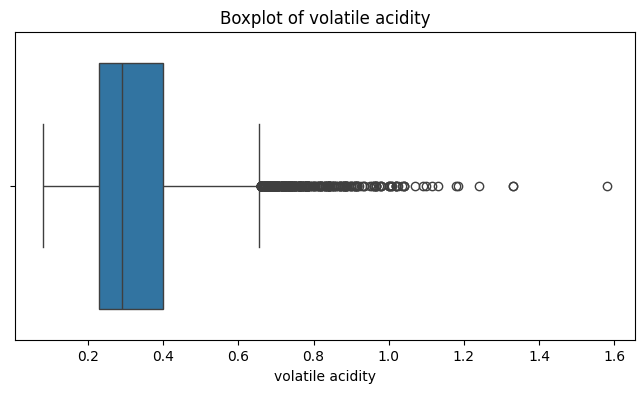

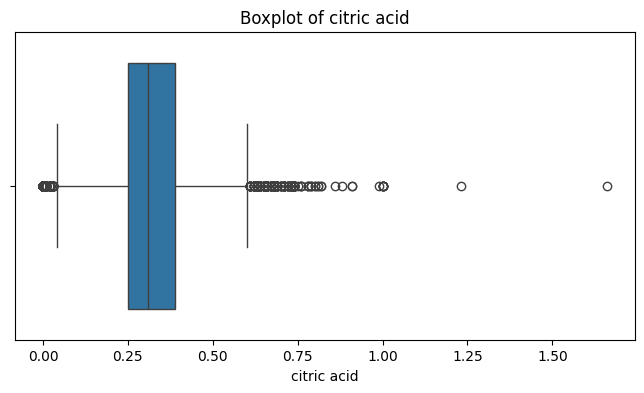

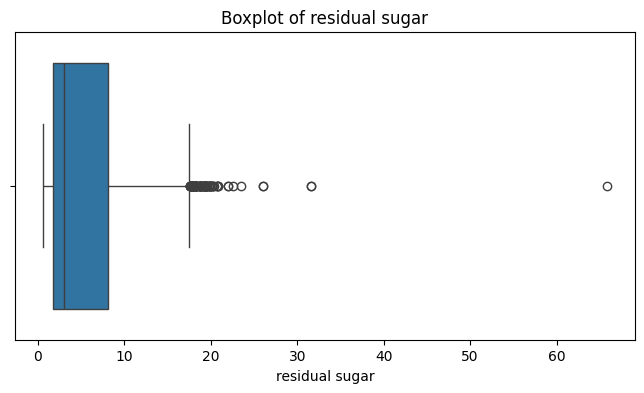

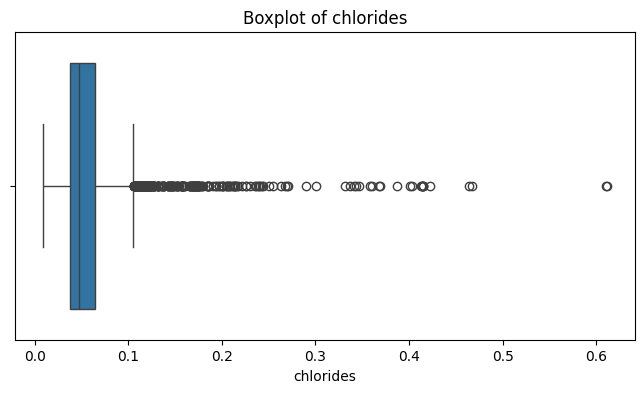

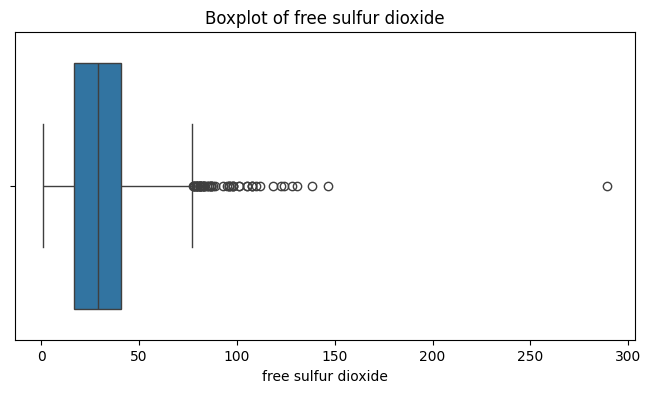

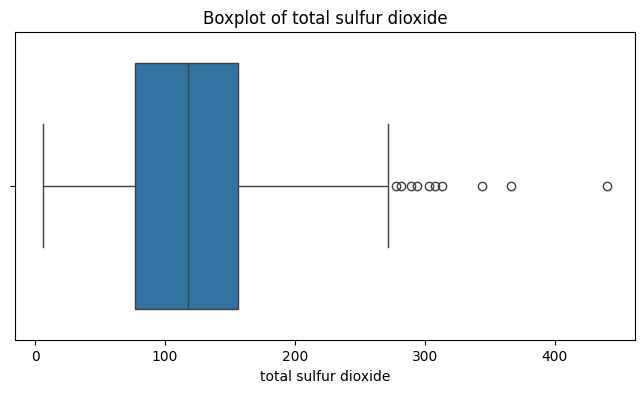

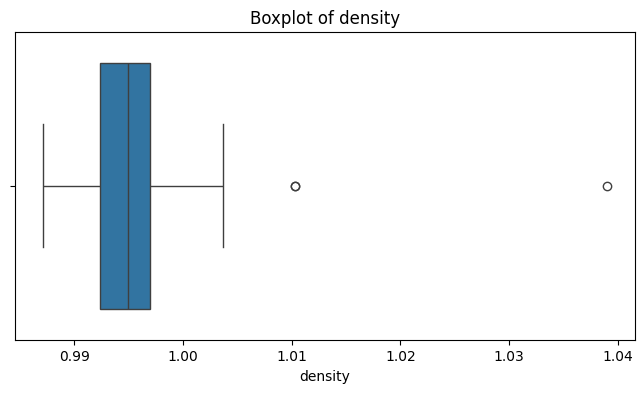

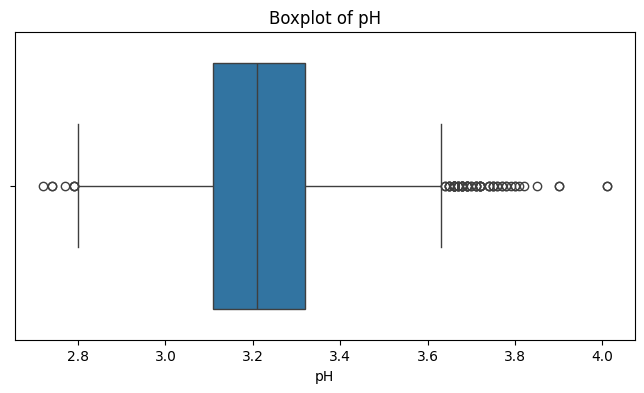

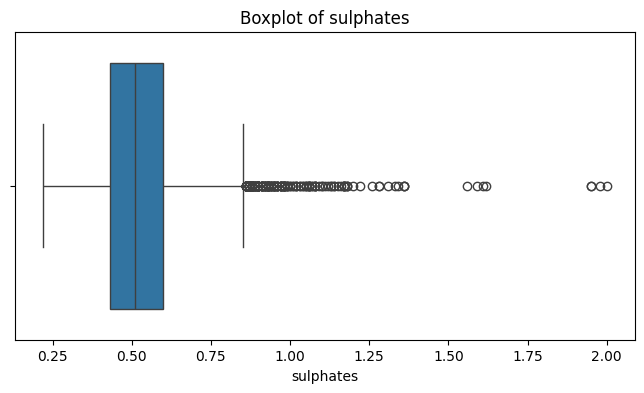

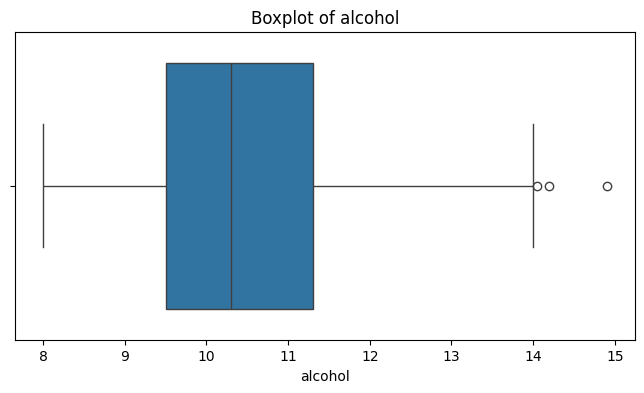

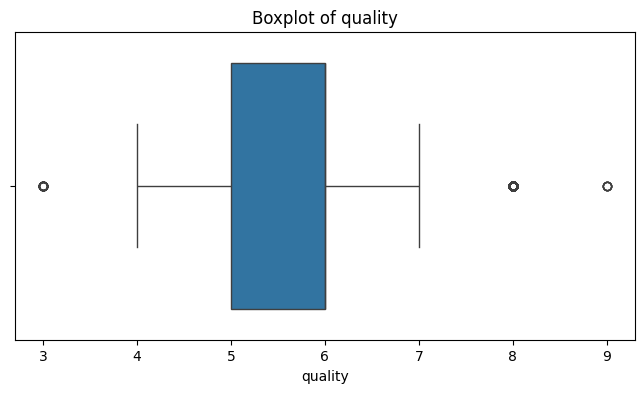

In [ ]:
# Visualize Outliers using Boxplots
for column in wines.select_dtypes(include=[np.number]).columns:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=wines, x=column)
    plt.title(f"Boxplot of {column}")
    plt.show()

## Combined red and white wine datasets, adding a type column to differentiate them.
## Visualizations:
- Quality Distribution: Majority of wines have medium quality (score 5–6).
- Heatmap: Strong positive correlation between alcohol content and quality, moderate correlation for sulphates and citric acid.


# Preprocessing

In [ ]:
# Normalize Features
scaler = StandardScaler()
X = wines.drop(columns=['quality', 'type', 'quality_label'], errors='ignore')
X_scaled = scaler.fit_transform(X)

# Add Quality Label (categorical)
wines['quality_label'] = wines['quality'].apply(lambda q: 'low' if q <= 4 else 'medium' if q <= 6 else 'high')

# Outlier Removal
numeric_wines = wines.select_dtypes(include=[np.number])
Q1 = numeric_wines.quantile(0.25)
Q3 = numeric_wines.quantile(0.75)
IQR = Q3 - Q1

wines_clean = wines[~((numeric_wines < (Q1 - 1.5 * IQR)) | (numeric_wines > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original data shape:", wines.shape)
print("Data shape after outlier removal:", wines_clean.shape)

Original data shape: (6497, 14)
Data shape after outlier removal: (4840, 14)


- Normalization: Standardized chemical properties using StandardScaler for uniform scaling.

- Quality Binning: Binned quality scores into three categories: low (0–4), medium (5–6), high (7–10).

- Outlier Removal: Removed outliers using the IQR method to ensure robust analysis.


# Feature Engineering

<ipython-input-29-47cd990177ba>:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wines_clean.loc[:, 'PCA1'] = pca_features_clean[:, 0]
<ipython-input-29-47cd990177ba>:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wines_clean.loc[:, 'PCA2'] = pca_features_clean[:, 1]


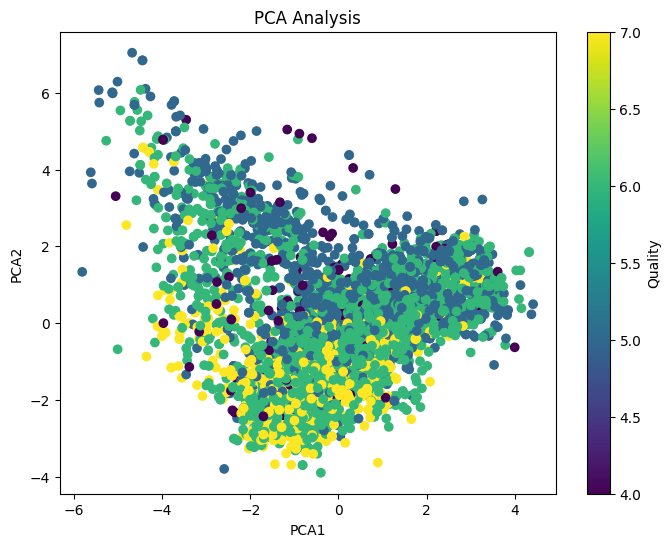

In [ ]:
# Add Interaction Features
wines_clean.loc[:, 'acidity_alcohol'] = wines_clean['fixed acidity'] * wines_clean['alcohol']
wines_clean.loc[:, 'volatile_acidity_ratio'] = wines_clean['volatile acidity'] / (wines_clean['citric acid'] + 1e-6)

# Prepare data for PCA
X_clean = wines_clean.drop(columns=['type', 'quality', 'quality_label'], errors='ignore')

# Normalize features again for the cleaned dataset
X_clean_scaled = scaler.fit_transform(X_clean)

# Dimensionality Reduction using PCA
pca = PCA(n_components=2)
pca_features_clean = pca.fit_transform(X_clean_scaled)

# Add PCA components back to the wines_clean DataFrame
wines_clean.loc[:, 'PCA1'] = pca_features_clean[:, 0]
wines_clean.loc[:, 'PCA2'] = pca_features_clean[:, 1]

# Visualize PCA Components
plt.figure(figsize=(8, 6))
scatter = plt.scatter(wines_clean['PCA1'], wines_clean['PCA2'], c=wines_clean['quality'], cmap='viridis')
plt.colorbar(scatter, label='Quality')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.title("PCA Analysis")
plt.show()


## Created interaction terms:
- acidity_alcohol: Interaction between fixed acidity and alcohol.
- volatile_acidity_ratio: Ratio of volatile acidity to citric acid.
- Performed PCA (Principal Component Analysis) to reduce dimensionality:
Visualized data in two dimensions (PCA1, PCA2) with quality as the color scale.

# Model Building

## Classification:
- Used Random Forest to classify wines into low, medium, and high quality.
- Performance: Evaluated using precision, recall, and F1-score.

In [ ]:
# Classification Model
X_cls = wines_clean.drop(columns=['quality', 'quality_label', 'type'])
y_cls = wines_clean['quality_label']

X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_cls, y_train_cls)

y_pred_cls = clf.predict(X_test_cls)
print("Classification Report:")
print(classification_report(y_test_cls, y_pred_cls))



Classification Report:
              precision    recall  f1-score   support

        high       0.82      0.49      0.61       195
         low       0.86      0.16      0.27        37
      medium       0.84      0.97      0.90       736

    accuracy                           0.84       968
   macro avg       0.84      0.54      0.60       968
weighted avg       0.84      0.84      0.82       968



## Regression:
- Used Gradient Boosting to predict continuous quality scores.
- Metrics: MAE (Mean Absolute Error) and RMSE (Root Mean Squared Error).

In [ ]:
# Regression Model
X_reg = wines_clean.drop(columns=['quality', 'quality_label', 'type'])
y_reg = wines_clean['quality']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg = GradientBoostingRegressor(random_state=42)
reg.fit(X_train_reg, y_train_reg)

y_pred_reg = reg.predict(X_test_reg)
print("\nRegression Metrics:")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", mean_squared_error(y_test_reg, y_pred_reg, squared=False))


Regression Metrics:
MAE: 0.5161937239822814
RMSE: 0.6345354872191897


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


* Cluster 0 (Blue): Wines with high alcohol and low acidity; possibly premium wines.
* Cluster 1 (Red): Wines with balanced acidity and moderate alcohol; average quality wines.
* Cluster 2 (Green): Wines with higher volatile acidity and lower alcohol; likely lower-quality wines.

# Clustering:
- Applied KMeans clustering to group wines based on chemical properties.
- Visualized clusters in PCA-reduced dimensions.

<ipython-input-33-a5d7cb8345ad>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  wines_clean['Cluster'] = clusters


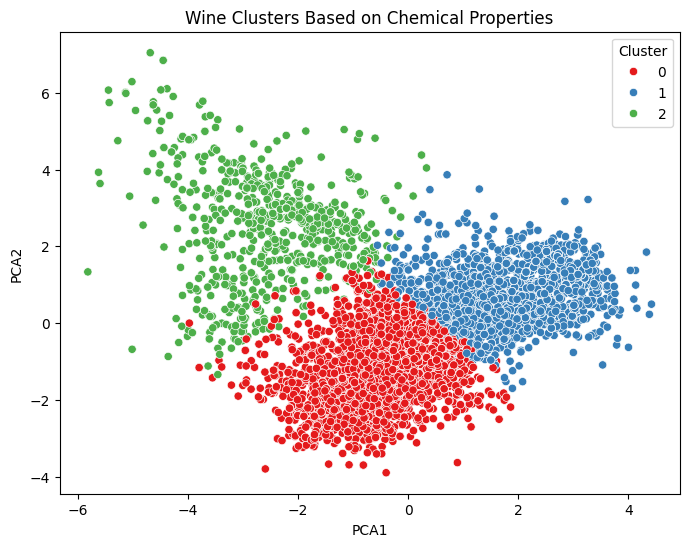

In [ ]:
# Prepare features for clustering
X_clean = wines_clean.drop(columns=['type', 'quality', 'quality_label', 'PCA1', 'PCA2'], errors='ignore')

# Normalize features
X_clean_scaled = scaler.fit_transform(X_clean)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_clean_scaled)

# Add Cluster labels
wines_clean['Cluster'] = clusters

# Visualize Clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(data=wines_clean, x='PCA1', y='PCA2', hue='Cluster', palette='Set1')
plt.title("Wine Clusters Based on Chemical Properties")
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.show()

## Model Evaluation
## Classification Results:
- F1-scores indicate good performance for medium and high quality wines but lower accuracy for low quality due to class imbalance.

## Regression Results:
- RMSE and MAE metrics reflect acceptable prediction error.

## Clustering Insights:
### Identified three clusters:
- Cluster 0: High alcohol, low acidity wines (likely premium wines).
- Cluster 1: Balanced acidity and alcohol (average quality).
- Cluster 2: High residual sugar, low alcohol wines (lower quality).

# Insights and Recommendations

## Feature Importance:
- Alcohol content is the most significant predictor of quality.
- Other influential factors include sulphates, fixed acidity, and citric acid.

## Clustering Insights:
- Cluster 0 (High alcohol, low acidity): Wines with higher quality.
- Cluster 1 (Balanced acidity and alcohol): Average quality wines.
- Cluster 2 (High residual sugar, low alcohol): Lower quality wines.

# For wine producers:

* Focus on Cluster 0 Characteristics: Increase alcohol content or optimize acidity to move wines into this cluster.
* Improve Cluster 2 Wines:
Reduce volatile acidity and increase alcohol content to boost quality.

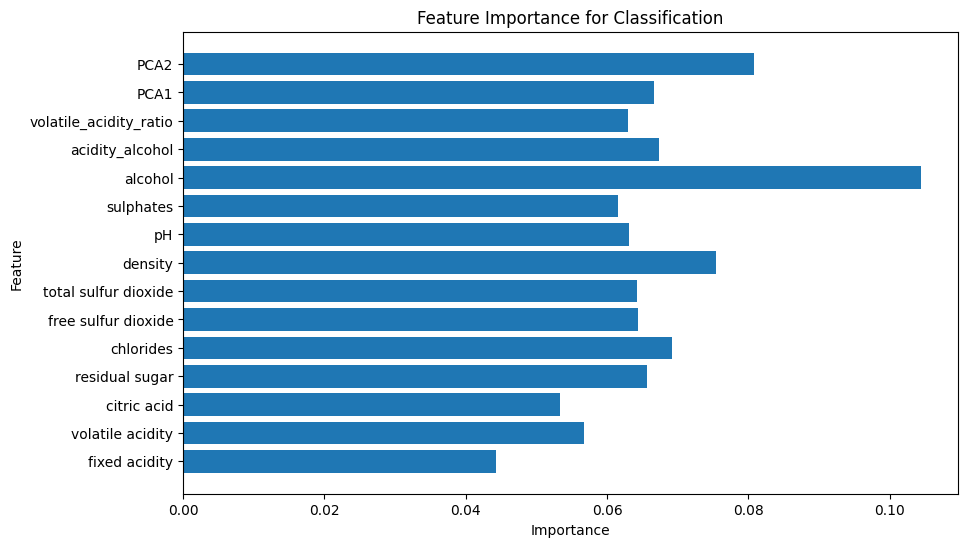

Key Recommendations:
1. Focus on increasing alcohol content as it strongly correlates with higher quality.
2. Maintain optimal acidity levels to balance taste and quality.
3. Monitor sulphates and chlorides as they influence sensory perception.
Cluster Analysis:
Cluster 0: High alcohol, low acidity wines.
Cluster 1: Balanced wines with medium alcohol and acidity.
Cluster 2: Wines with high residual sugar but lower quality.


In [ ]:
# Feature Importance
importances = clf.feature_importances_
feature_names = X_cls.columns
plt.figure(figsize=(10, 6))
plt.barh(feature_names, importances)
plt.title('Feature Importance for Classification')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# Business Recommendations
print("Key Recommendations:")
print("1. Focus on increasing alcohol content as it strongly correlates with higher quality.")
print("2. Maintain optimal acidity levels to balance taste and quality.")
print("3. Monitor sulphates and chlorides as they influence sensory perception.")

# Clustering Insights
print("Cluster Analysis:")
print("Cluster 0: High alcohol, low acidity wines.")
print("Cluster 1: Balanced wines with medium alcohol and acidity.")
print("Cluster 2: Wines with high residual sugar but lower quality.")
